## 1. Environment Setup

This section imports all required libraries and defines global constants used throughout the experiment.

**Reproducibility** is ensured by fixing the random seed to 42 across Python, NumPy, and PyTorch — guaranteeing identical results across runs.

**Directory structure:**
- `DATA_DIR` — raw RDD2022 dataset split into train/val/test
- `LOGS_DIR` — training logs
- `PLOTS_DIR` — saved figures and visualizations
- `SAVED_DIR` — model checkpoints

**Dataset constants:**
- 4 damage classes: `D00` (longitudinal crack), `D10` (transverse crack), `D20` (alligator crack), `D40` (pothole)
- 6 countries included: China (MotorBike), Czech Republic, India, Japan, Norway, United States
- `China_Drone` is excluded from all experiments — drone imagery uses a top-down capture angle fundamentally different from the ground-level smartphone images in all other countries, and contains an additional class (class 4) not present in the official CRDDC'2022 benchmark

In [17]:
import os
import sys
import shutil
import random
import yaml
import json
from pathlib import Path
from collections import defaultdict

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

#For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

#paths
BASE_DIR  = Path("/home/jupyter-st126222/Project/rdd2022")
DATA_DIR  = BASE_DIR / "data" / "RDD_SPLIT"
LOGS_DIR  = BASE_DIR / "logs"
PLOTS_DIR = BASE_DIR / "plots"
SAVED_DIR = BASE_DIR / "saved"

for d in [LOGS_DIR, PLOTS_DIR, SAVED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

#constants
CLASSES   = ["D00", "D10", "D20", "D40"]
NUM_CLASSES = 4
COUNTRIES = ["China_MotorBike", "Czech", "India", "Japan", "Norway", "United_States"]
EXCLUDE   = ["China_Drone"]

print("Imports OK")
print(f"  DATA_DIR : {DATA_DIR}")
print(f"  Device   : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Imports OK
  DATA_DIR : /home/jupyter-st126222/Project/rdd2022/data/RDD_SPLIT
  Device   : NVIDIA GeForce RTX 2080 Ti


## 2. Dataset Exploration

### 2.1 Image Count per Country

We define a helper function `get_country()` that extracts the country prefix from each filename 
(e.g. `Japan_000001.jpg` → `Japan`) and use it to count images per country across all three splits.

In [5]:
# Dataset exploration
def get_country(filename):
    # Extract country prefix from filename e.g. "Japan_000001.jpg" -> "Japan"
    for country in COUNTRIES + EXCLUDE:
        if filename.startswith(country):
            return country
    return "Unknown"

# Count images per country per split
stats = {}
for split in ["train", "val", "test"]:
    img_dir = DATA_DIR / split / "images"
    counts = defaultdict(int)
    for f in img_dir.iterdir():
        country = get_country(f.name)
        counts[country] += 1
    stats[split] = dict(counts)

# Print table
print(f"{'Country':<20} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 48)
for country in COUNTRIES + EXCLUDE:
    tr = stats['train'].get(country, 0)
    va = stats['val'].get(country, 0)
    te = stats['test'].get(country, 0)
    flag = " - excluded" if country in EXCLUDE else ""
    print(f"{country:<20} {tr:>8} {va:>8} {te:>8}{flag}")

print("-" * 48)
total_tr = sum(stats['train'].get(c, 0) for c in COUNTRIES)
total_va = sum(stats['val'].get(c, 0) for c in COUNTRIES)
total_te = sum(stats['test'].get(c, 0) for c in COUNTRIES)
print(f"{'TOTAL (used)':<20} {total_tr:>8} {total_va:>8} {total_te:>8}")

Country                 Train      Val     Test
------------------------------------------------
China_MotorBike          1376      296      305
Czech                    1962      431      436
India                    5368     1172     1166
Japan                    7432     1550     1524
Norway                   5708     1256     1197
United_States            3348      704      753
China_Drone              1675      349      377 - excluded
------------------------------------------------
TOTAL (used)            25194     5409     5381


### 2.2 Class Distribution

We count bounding box annotations per damage class across all training labels, 
excluding China_Drone images. Labels with class index ≥ 4 are ignored to enforce 
the 4-class CRDDC'2022 standard.

Class distribution in training set:
Class  Name                    Count        %
----------------------------------------------
0      D00                     17219    44.1%
1      D10                      7507    19.2%
2      D20                      7320    18.7%
3      D40                      7029    18.0%
----------------------------------------------
Total                         39075


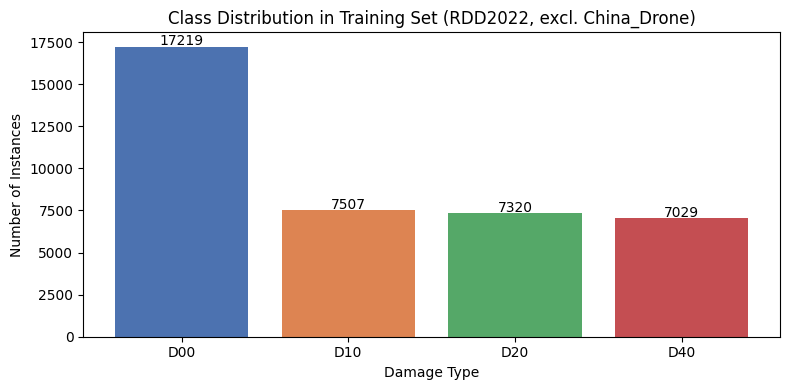

✓ Saved to /home/jupyter-st126222/Project/rdd2022/plots/class_distribution.png


In [6]:
# Class distribution in training set (excluding China_Drone)
label_dir = DATA_DIR / "train" / "labels"
class_counts = defaultdict(int)

for f in label_dir.iterdir():
    if get_country(f.name) in EXCLUDE:
        continue
    with open(f) as fp:
        for line in fp:
            line = line.strip()
            if line:
                cls = int(line.split()[0])
                if cls < NUM_CLASSES:  # only 0-3
                    class_counts[cls] += 1

print("Class distribution in training set:")
print(f"{'Class':<6} {'Name':<20} {'Count':>8} {'%':>8}")
print("-" * 46)
total = sum(class_counts.values())
for cls_id, name in enumerate(CLASSES):
    count = class_counts[cls_id]
    print(f"{cls_id:<6} {name:<20} {count:>8} {count/total*100:>7.1f}%")
print("-" * 46)
print(f"{'Total':<26} {total:>8}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(CLASSES, [class_counts[i] for i in range(NUM_CLASSES)],
              color=["#4C72B0","#DD8452","#55A868","#C44E52"])
ax.set_title("Class Distribution in Training Set (RDD2022, excl. China_Drone)")
ax.set_xlabel("Damage Type")
ax.set_ylabel("Number of Instances")
for bar, count in zip(bars, [class_counts[i] for i in range(NUM_CLASSES)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            str(count), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "class_distribution.png", dpi=150)
plt.show()
print(f"✓ Saved to {PLOTS_DIR / 'class_distribution.png'}")

This imbalance has two important implications for our experiments:
1. The model may develop a bias toward predicting D00, inflating overall mAP 
while underperforming on minority classes
2. Per-class AP scores (AP-D00, AP-D10, AP-D20, AP-D40) are a more informative 
metric than aggregate mAP alone — we report both throughout this study

### 2.3 Sample Images per Country

We visualize one representative image from each country with ground truth bounding 
boxes overlaid. Boxes are color-coded by damage type:
- 🔴 Red — D00 (longitudinal crack)
- 🔵 Blue — D10 (transverse crack)  
- 🟢 Green — D20 (alligator crack)
- 🟠 Orange — D40 (pothole)

The `show_sample()` function converts YOLO format annotations (normalized center x, 
center y, width, height) back to pixel coordinates for visualization.

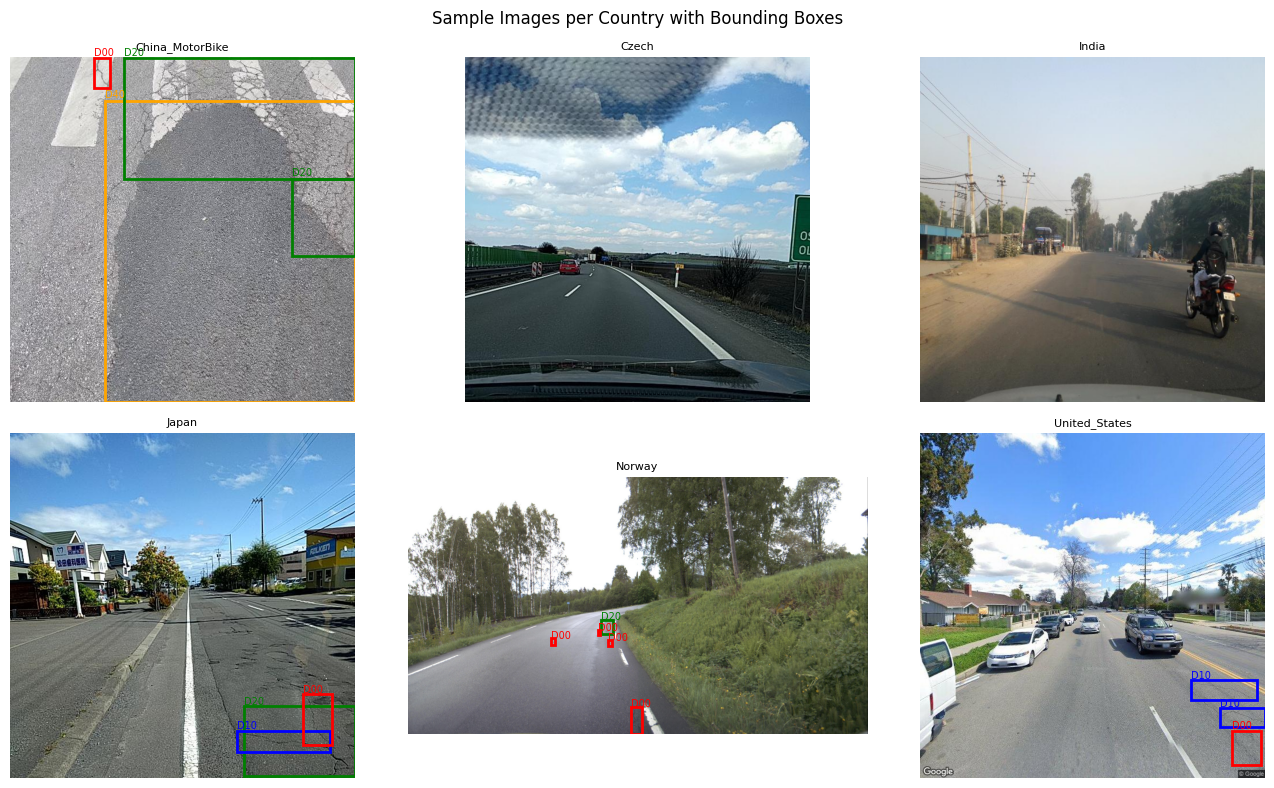

✓ Saved to /home/jupyter-st126222/Project/rdd2022/plots/sample_images.png


In [7]:
# Visualize sample images with bounding boxes per country
COLOR_MAP = {0: "red", 1: "blue", 2: "green", 3: "orange"}

def show_sample(img_path, label_path, ax, title):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    ax.imshow(img)
    ax.set_title(title, fontsize=8)
    ax.axis("off")
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                cls = int(parts[0])
                if cls >= NUM_CLASSES: continue
                cx, cy, bw, bh = map(float, parts[1:])
                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                         linewidth=2, edgecolor=COLOR_MAP[cls],
                                         facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-5, CLASSES[cls], color=COLOR_MAP[cls], fontsize=7)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

img_dir   = DATA_DIR / "train" / "images"
label_dir = DATA_DIR / "train" / "labels"

for i, country in enumerate(COUNTRIES):
    # pick first available image for this country
    imgs = sorted([f for f in img_dir.iterdir() if f.name.startswith(country)])
    if not imgs: continue
    img_path   = imgs[0]
    label_path = label_dir / (img_path.stem + ".txt")
    show_sample(img_path, label_path, axes[i], country)

plt.suptitle("Sample Images per Country with Bounding Boxes", fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "sample_images.png", dpi=150)
plt.show()
print(f"✓ Saved to {PLOTS_DIR / 'sample_images.png'}")

### 2.4 Filtered Dataset Preparation

We create a filtered version of the dataset (`RDD_FILTERED`) that excludes 
China_Drone images. 

**Final dataset size after filtering:**
- Train: 25,194 images
- Val: 5,409 images  
- Test: 5,381 images

In [6]:
# Create filtered image/label lists and YAML config for YOLOv5/v8
FILTERED_DIR = BASE_DIR / "data" / "RDD_FILTERED"

for split in ["train", "val", "test"]:
    (FILTERED_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (FILTERED_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

    img_dir   = DATA_DIR / split / "images"
    label_dir = DATA_DIR / split / "labels"
    out_img   = FILTERED_DIR / split / "images"
    out_lbl   = FILTERED_DIR / split / "labels"

    count = 0
    for img_path in sorted(img_dir.iterdir()):
        country = get_country(img_path.name)
        if country in EXCLUDE:
            continue
        # symlink images and labels (saves disk space)
        dst_img = out_img / img_path.name
        if not dst_img.exists():
            dst_img.symlink_to(img_path.resolve())
        lbl_path = label_dir / (img_path.stem + ".txt")
        dst_lbl  = out_lbl / lbl_path.name
        if lbl_path.exists() and not dst_lbl.exists():
            dst_lbl.symlink_to(lbl_path.resolve())
        count += 1
    print(f"✓ {split}: {count} images")

# Write YAML config
yaml_content = {
    "path"  : str(FILTERED_DIR),
    "train" : "train/images",
    "val"   : "val/images",
    "test"  : "test/images",
    "nc"    : NUM_CLASSES,
    "names" : CLASSES
}
yaml_path = BASE_DIR / "data" / "rdd2022.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print(f"\n✓ YAML config saved to {yaml_path}")
print(yaml.dump(yaml_content, default_flow_style=False))

✓ train: 25194 images
✓ val: 5409 images
✓ test: 5381 images

✓ YAML config saved to /home/jupyter-st126222/Project/rdd2022/data/rdd2022.yaml
names:
- D00
- D10
- D20
- D40
nc: 4
path: /home/jupyter-st126222/Project/rdd2022/data/RDD_FILTERED
test: test/images
train: train/images
val: val/images



### 2.5 Bounding Box Area Distribution per Class 
We compute the area of each bounding box as a percentage of the total image area (width × height × 100) and plot the distribution per damage class. This reveals the scale at which each damage type appears in the image — a critical factor in determining which detection architecture is most appropriate.

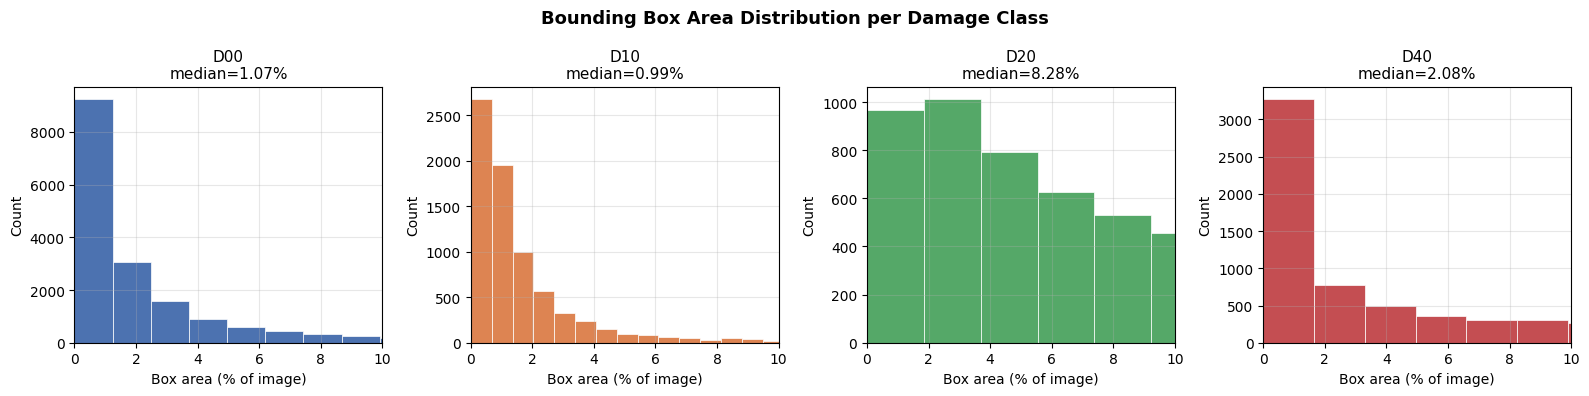

✓ Saved to /home/jupyter-st126222/Project/rdd2022/plots/bbox_area_distribution.png

Class  Name                  Median Area    Mean Area        Std
--------------------------------------------------------------
0      D00                        1.066%       2.500%     4.098%
1      D10                        0.988%       1.836%     2.648%
2      D20                        8.277%      12.255%    12.362%
3      D40                        2.080%       6.054%     9.245%


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict

# Collect bounding box areas per class
box_areas = defaultdict(list)

label_dir = DATA_DIR / "train" / "labels"
for f in label_dir.iterdir():
    if get_country(f.name) in EXCLUDE:
        continue
    with open(f) as fp:
        for line in fp:
            parts = line.strip().split()
            if not parts: continue
            cls = int(parts[0])
            if cls >= NUM_CLASSES: continue
            w, h = float(parts[3]), float(parts[4])
            area = w * h * 100  # as % of image area
            box_areas[cls].append(area)

# Plot
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for cls_id, (name, color) in enumerate(zip(CLASSES, colors)):
    areas = box_areas[cls_id]
    axes[cls_id].hist(areas, bins=50, color=color, edgecolor="white", linewidth=0.5)
    axes[cls_id].set_title(f"{name}\nmedian={np.median(areas):.2f}%", fontsize=11)
    axes[cls_id].set_xlabel("Box area (% of image)")
    axes[cls_id].set_ylabel("Count")
    axes[cls_id].set_xlim(0, 10)
    axes[cls_id].grid(alpha=0.3)

plt.suptitle("Bounding Box Area Distribution per Damage Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "bbox_area_distribution.png", dpi=150)
plt.show()
print(f"✓ Saved to {PLOTS_DIR / 'bbox_area_distribution.png'}")

# Print summary
print(f"\n{'Class':<6} {'Name':<20} {'Median Area':>12} {'Mean Area':>12} {'Std':>10}")
print("-" * 62)
for cls_id, name in enumerate(CLASSES):
    areas = box_areas[cls_id]
    print(f"{cls_id:<6} {name:<20} {np.median(areas):>11.3f}% {np.mean(areas):>11.3f}% {np.std(areas):>9.3f}%")

### 2.6 Damage Type Distribution per Country

We compute the percentage of each damage type per country to reveal how road damage 
profiles differ across nations. Each country's bar sums to 100%.

Notable patterns: Norway is dominated by D00 (80%) with zero potholes, Japan has 
the highest pothole share (37%), India is uniquely alligator crack-heavy (40%), 
and both Czech and Norway record zero D40 instances. These stark differences in 
damage composition directly motivate the cross-country generalization experiments 
in RQ3 — a model trained on Norway's crack-only roads will have never seen a 
pothole during training.

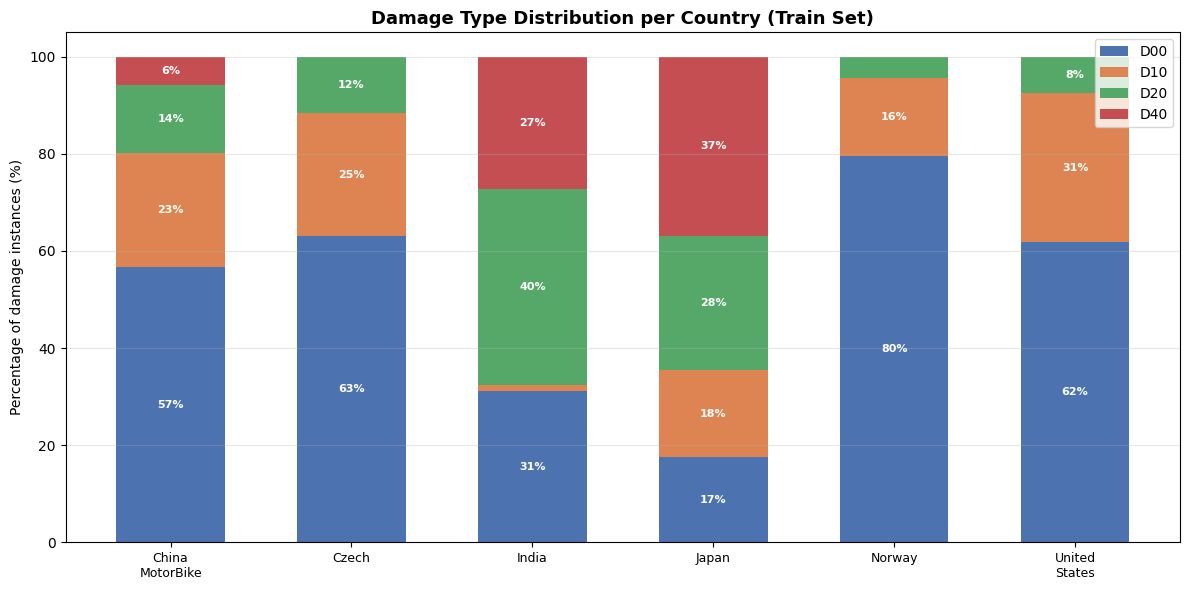

✓ Saved to /home/jupyter-st126222/Project/rdd2022/plots/damage_per_country.png

Country                    D00       D10       D20       D40     Total
------------------------------------------------------------
China_MotorBike           1861       769       464       189      3283
Czech                      682       275       126         0      1083
India                     1103        50      1428       969      3550
Japan                     2781      2847      4395      5871     15894
Norway                    6080      1226       334         0      7640
United_States             4712      2340       573         0      7625


In [11]:
# Damage type per country stacked bar chart
country_class_counts = defaultdict(lambda: defaultdict(int))

label_dir = DATA_DIR / "train" / "labels"
for f in label_dir.iterdir():
    country = get_country(f.name)
    if country in EXCLUDE: continue
    with open(f) as fp:
        for line in fp:
            parts = line.strip().split()
            if not parts: continue
            cls = int(parts[0])
            if cls >= NUM_CLASSES: continue
            country_class_counts[country][cls] += 1

# Normalize to percentage per country
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(COUNTRIES))
width = 0.6
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bottoms = np.zeros(len(COUNTRIES))

for cls_id, (name, color) in enumerate(zip(CLASSES, colors)):
    counts = []
    for country in COUNTRIES:
        total = sum(country_class_counts[country].values())
        count = country_class_counts[country][cls_id]
        counts.append(count / total * 100 if total > 0 else 0)
    ax.bar(x, counts, width, bottom=bottoms, label=name, color=color)
    # Add percentage labels
    for i, (count, bottom) in enumerate(zip(counts, bottoms)):
        if count > 5:
            ax.text(i, bottom + count/2, f"{count:.0f}%",
                   ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    bottoms += np.array(counts)

ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", "\n") for c in COUNTRIES], fontsize=9)
ax.set_ylabel("Percentage of damage instances (%)")
ax.set_title("Damage Type Distribution per Country (Train Set)", fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "damage_per_country.png", dpi=150)
plt.show()
print(f"✓ Saved to {PLOTS_DIR / 'damage_per_country.png'}")

# Print raw numbers
print(f"\n{'Country':<20}", end="")
for name in CLASSES:
    print(f"{name:>10}", end="")
print(f"{'Total':>10}")
print("-" * 60)
for country in COUNTRIES:
    total = sum(country_class_counts[country].values())
    print(f"{country:<20}", end="")
    for cls_id in range(NUM_CLASSES):
        print(f"{country_class_counts[country][cls_id]:>10}", end="")
    print(f"{total:>10}")

### 2.7 Average Damage Instances per Image per Country

We compute the mean number of annotations per image per class per country, 
measuring how densely damaged each country's roads are.

Japan has the highest pothole density (0.790 per image), United States and 
China_MotorBike have the most longitudinal cracks (1.407 and 1.352 respectively), 
while Czech and Norway record zero D40 instances across all images. India has 
almost no D10 (0.009 per image). These density differences compound the 
distribution shift problem — not only do damage types differ across countries, 
but their frequency per image differs significantly as well.

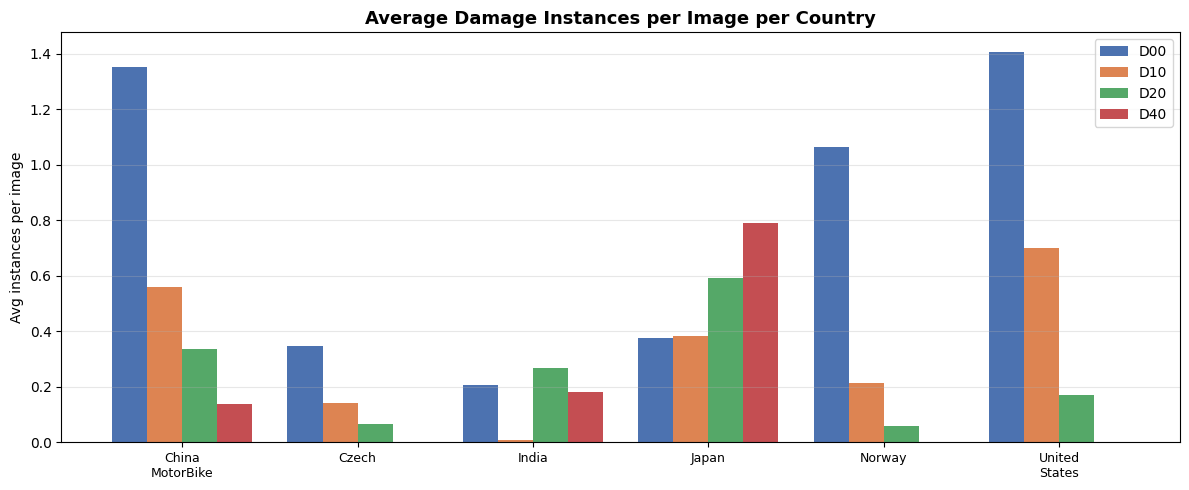

✓ Saved to /home/jupyter-st126222/Project/rdd2022/plots/damage_density_per_country.png

Country                    D00       D10       D20       D40
------------------------------------------------------------
China_MotorBike          1.352     0.559     0.337     0.137
Czech                    0.348     0.140     0.064     0.000
India                    0.205     0.009     0.266     0.181
Japan                    0.374     0.383     0.591     0.790
Norway                   1.065     0.215     0.059     0.000
United_States            1.407     0.699     0.171     0.000


In [12]:
# Average damage instances per image per country
fig, ax = plt.subplots(figsize=(12, 5))

density_data = defaultdict(lambda: defaultdict(list))
label_dir = DATA_DIR / "train" / "labels"

for f in label_dir.iterdir():
    country = get_country(f.name)
    if country in EXCLUDE: continue
    class_counts_img = defaultdict(int)
    with open(f) as fp:
        for line in fp:
            parts = line.strip().split()
            if not parts: continue
            cls = int(parts[0])
            if cls >= NUM_CLASSES: continue
            class_counts_img[cls] += 1
    for cls_id in range(NUM_CLASSES):
        density_data[country][cls_id].append(class_counts_img[cls_id])

x = np.arange(len(COUNTRIES))
width = 0.2
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for cls_id, (name, color) in enumerate(zip(CLASSES, colors)):
    means = [np.mean(density_data[c][cls_id]) for c in COUNTRIES]
    ax.bar(x + cls_id * width, means, width, label=name, color=color)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([c.replace("_", "\n") for c in COUNTRIES], fontsize=9)
ax.set_ylabel("Avg instances per image")
ax.set_title("Average Damage Instances per Image per Country", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "damage_density_per_country.png", dpi=150)
plt.show()
print(f"✓ Saved to {PLOTS_DIR / 'damage_density_per_country.png'}")

# Print table
print(f"\n{'Country':<20}", end="")
for name in CLASSES:
    print(f"{name:>10}", end="")
print()
print("-" * 60)
for country in COUNTRIES:
    print(f"{country:<20}", end="")
    for cls_id in range(NUM_CLASSES):
        mean = np.mean(density_data[country][cls_id])
        print(f"{mean:>10.3f}", end="")
    print()

### 2.8 Spatial Distribution of Damage Instances

We divide each image into a 20×20 grid and accumulate bounding box center counts 
per cell to reveal where each damage type tends to appear spatially.

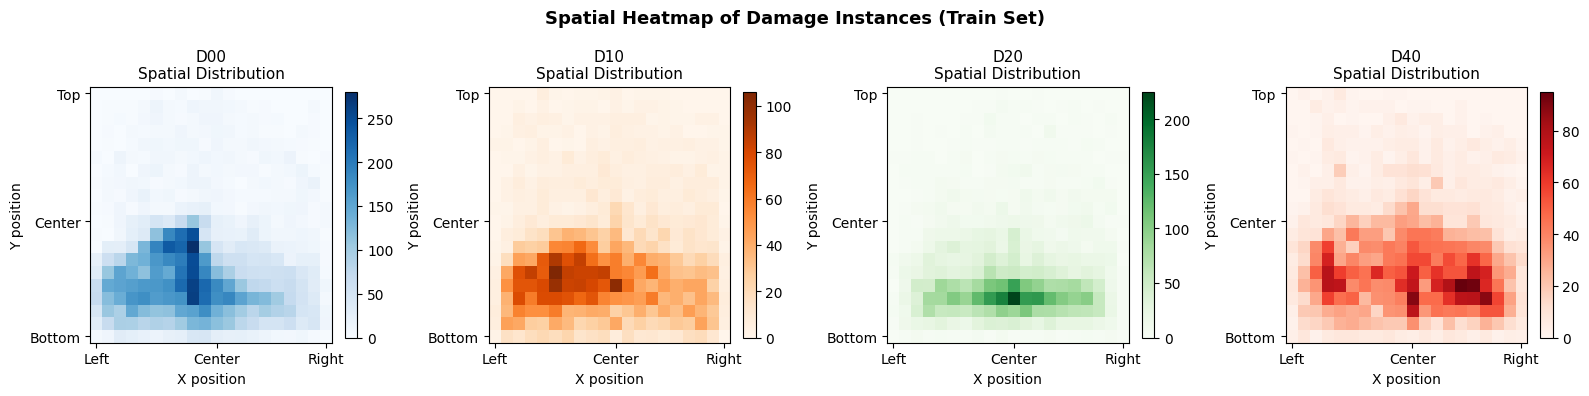

✓ Saved to /home/jupyter-st126222/Project/rdd2022/plots/bbox_spatial_heatmap.png


In [13]:
# Where on the image do damage types appear?
import numpy as np
import matplotlib.pyplot as plt

GRID = 20  # 20x20 grid
heatmaps = {cls_id: np.zeros((GRID, GRID)) for cls_id in range(NUM_CLASSES)}

label_dir = DATA_DIR / "train" / "labels"
for f in label_dir.iterdir():
    country = get_country(f.name)
    if country in EXCLUDE: continue
    with open(f) as fp:
        for line in fp:
            parts = line.strip().split()
            if not parts: continue
            cls = int(parts[0])
            if cls >= NUM_CLASSES: continue
            cx, cy = float(parts[1]), float(parts[2])
            gx = min(int(cx * GRID), GRID - 1)
            gy = min(int(cy * GRID), GRID - 1)
            heatmaps[cls][gy, gx] += 1

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = CLASSES
cmaps = ["Blues", "Oranges", "Greens", "Reds"]

for cls_id, (ax, title, cmap) in enumerate(zip(axes, titles, cmaps)):
    h = heatmaps[cls_id]
    im = ax.imshow(h, cmap=cmap, aspect="auto")
    ax.set_title(f"{title}\nSpatial Distribution", fontsize=11)
    ax.set_xlabel("X position")
    ax.set_ylabel("Y position")
    ax.set_xticks([0, GRID//2, GRID-1])
    ax.set_xticklabels(["Left", "Center", "Right"])
    ax.set_yticks([0, GRID//2, GRID-1])
    ax.set_yticklabels(["Top", "Center", "Bottom"])
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Spatial Heatmap of Damage Instances (Train Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "bbox_spatial_heatmap.png", dpi=150)
plt.show()
print(f"✓ Saved to {PLOTS_DIR / 'bbox_spatial_heatmap.png'}")

### 2.9 Damage Type Co-occurrence Matrix

We compute how often each pair of damage types appears in the same image. 
The normalized matrix shows the percentage of images containing the row class 
that also contain the column class.

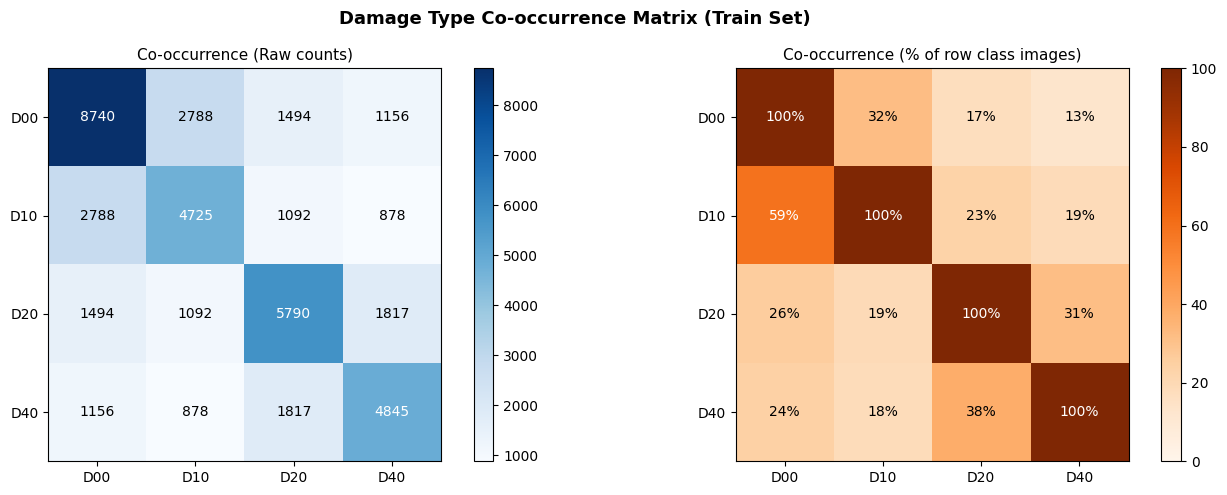

✓ Saved to /home/jupyter-st126222/Project/rdd2022/plots/cooccurrence_matrix.png


In [14]:
# Co-occurrence matrix — which damage types appear in the same image
cooccurrence = np.zeros((NUM_CLASSES, NUM_CLASSES))

label_dir = DATA_DIR / "train" / "labels"
for f in label_dir.iterdir():
    country = get_country(f.name)
    if country in EXCLUDE: continue
    classes_in_img = set()
    with open(f) as fp:
        for line in fp:
            parts = line.strip().split()
            if not parts: continue
            cls = int(parts[0])
            if cls < NUM_CLASSES:
                classes_in_img.add(cls)
    for c1 in classes_in_img:
        for c2 in classes_in_img:
            cooccurrence[c1, c2] += 1

# Normalize by diagonal (% of images containing c1 that also contain c2)
cooccurrence_norm = np.zeros_like(cooccurrence)
for i in range(NUM_CLASSES):
    if cooccurrence[i, i] > 0:
        cooccurrence_norm[i] = cooccurrence[i] / cooccurrence[i, i] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
im1 = axes[0].imshow(cooccurrence, cmap="Blues")
axes[0].set_title("Co-occurrence (Raw counts)", fontsize=11)
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_yticks(range(NUM_CLASSES))
axes[0].set_xticklabels(CLASSES)
axes[0].set_yticklabels(CLASSES)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        axes[0].text(j, i, f"{int(cooccurrence[i,j])}", 
                    ha="center", va="center", fontsize=10,
                    color="white" if cooccurrence[i,j] > cooccurrence.max()*0.5 else "black")
plt.colorbar(im1, ax=axes[0])

# Normalized
im2 = axes[1].imshow(cooccurrence_norm, cmap="Oranges", vmin=0, vmax=100)
axes[1].set_title("Co-occurrence (% of row class images)", fontsize=11)
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_yticks(range(NUM_CLASSES))
axes[1].set_xticklabels(CLASSES)
axes[1].set_yticklabels(CLASSES)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        axes[1].text(j, i, f"{cooccurrence_norm[i,j]:.0f}%",
                    ha="center", va="center", fontsize=10,
                    color="white" if cooccurrence_norm[i,j] > 50 else "black")
plt.colorbar(im2, ax=axes[1])

plt.suptitle("Damage Type Co-occurrence Matrix (Train Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "cooccurrence_matrix.png", dpi=150)
plt.show()
print(f"✓ Saved to {PLOTS_DIR / 'cooccurrence_matrix.png'}")

### 2.10 Image Brightness Distribution per Country

We sample 100 random images per country, convert each to grayscale, and compute 
the mean pixel brightness as a proxy for imaging conditions and lighting environment.

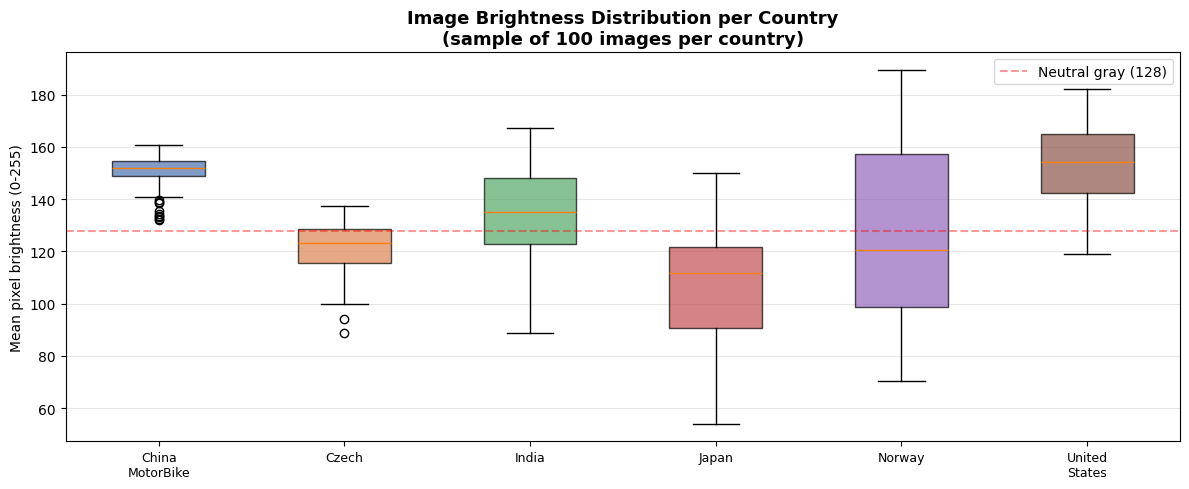

✓ Saved to /home/jupyter-st126222/Project/rdd2022/plots/brightness_per_country.png

Country                  Mean      Std      Min      Max
--------------------------------------------------------
China_MotorBike         150.5      6.4    132.1    160.8
Czech                   121.1      9.8     88.7    137.4
India                   133.8     18.7     88.9    167.3
Japan                   105.8     23.5     54.1    150.2
Norway                  127.3     35.1     70.4    189.5
United_States           152.9     15.2    119.1    182.1


In [15]:
from PIL import Image
import random

# Sample 100 images per country for brightness analysis
brightness_data = defaultdict(list)
img_dir = DATA_DIR / "train" / "images"

all_imgs = list(img_dir.iterdir())
random.shuffle(all_imgs)

for img_path in all_imgs:
    country = get_country(img_path.name)
    if country in EXCLUDE: continue
    if len(brightness_data[country]) >= 100: continue
    try:
        img = Image.open(img_path).convert("L")  # grayscale
        brightness = np.array(img).mean()
        brightness_data[country].append(brightness)
    except:
        continue
    if all(len(brightness_data[c]) >= 100 for c in COUNTRIES):
        break

fig, ax = plt.subplots(figsize=(12, 5))
data_to_plot = [brightness_data[c] for c in COUNTRIES]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False)

colors_bp = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#9467BD", "#8C564B"]
for patch, color in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels([c.replace("_", "\n") for c in COUNTRIES], fontsize=9)
ax.set_ylabel("Mean pixel brightness (0-255)")
ax.set_title("Image Brightness Distribution per Country\n(sample of 100 images per country)", 
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.axhline(y=128, color="red", linestyle="--", alpha=0.4, label="Neutral gray (128)")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "brightness_per_country.png", dpi=150)
plt.show()

print(f"✓ Saved to {PLOTS_DIR / 'brightness_per_country.png'}")
print(f"\n{'Country':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 56)
for country in COUNTRIES:
    vals = brightness_data[country]
    print(f"{country:<20} {np.mean(vals):>8.1f} {np.std(vals):>8.1f} {np.min(vals):>8.1f} {np.max(vals):>8.1f}")


### 2.11 Distribution of Damage Instances per Image

We count the total number of damage annotations per image for each country and plot the distribution as a histogram. The red dashed line marks the country mean.

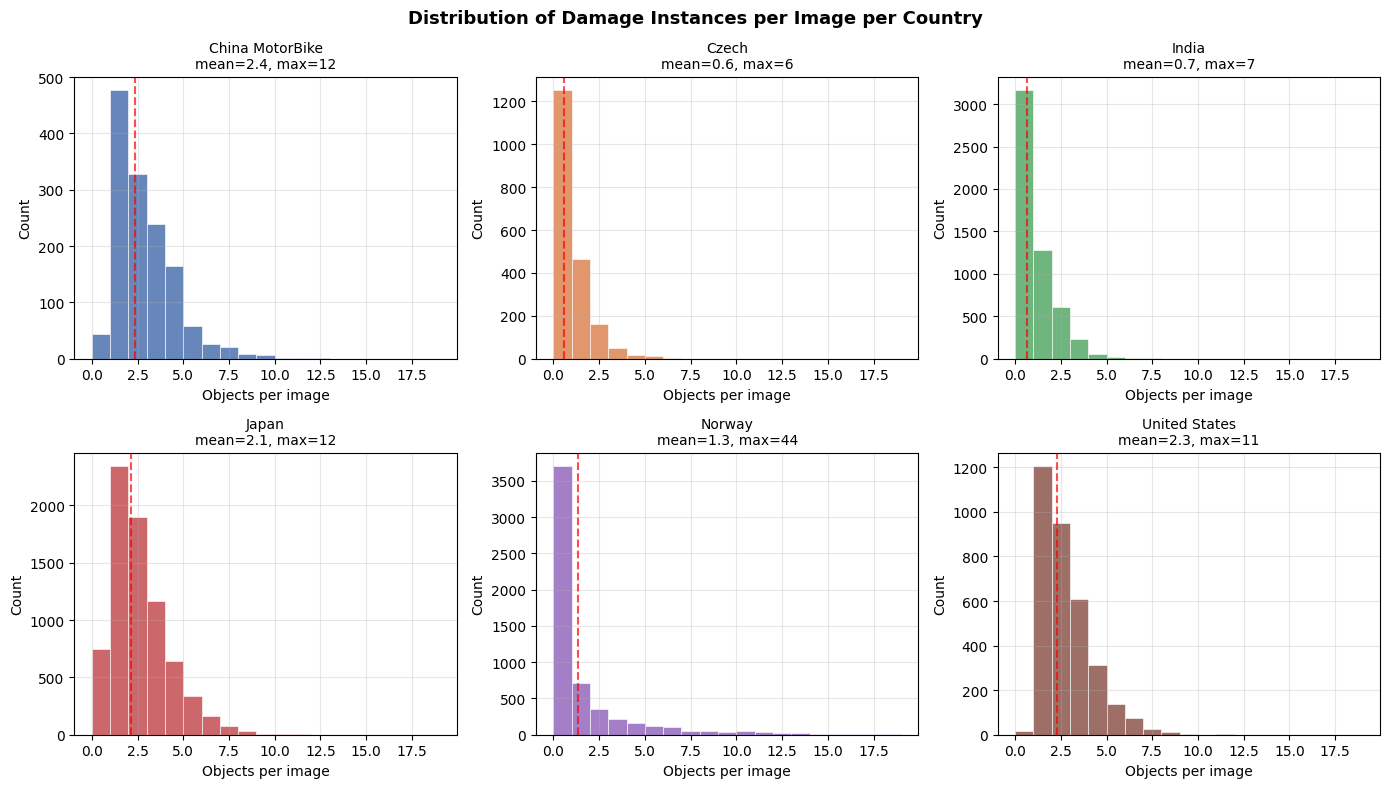

✓ Saved to /home/jupyter-st126222/Project/rdd2022/plots/objects_per_image.png

Country                  Mean   Median      Max    % empty
----------------------------------------------------------
China_MotorBike          2.39      2.0       12       3.1%
Czech                    0.55      0.0        6      63.9%
India                    0.66      0.0        7      59.0%
Japan                    2.14      2.0       12      10.1%
Norway                   1.34      0.0       44      64.9%
United_States            2.28      2.0       11       0.5%


In [16]:
# Number of objects per image distribution
obj_counts = defaultdict(list)

label_dir = DATA_DIR / "train" / "labels"
for f in label_dir.iterdir():
    country = get_country(f.name)
    if country in EXCLUDE: continue
    count = 0
    with open(f) as fp:
        for line in fp:
            parts = line.strip().split()
            if not parts: continue
            cls = int(parts[0])
            if cls < NUM_CLASSES:
                count += 1
    obj_counts[country].append(count)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, country in enumerate(COUNTRIES):
    counts = obj_counts[country]
    axes[i].hist(counts, bins=range(0, 20), color=colors_bp[i],
                 edgecolor="white", linewidth=0.5, alpha=0.85)
    axes[i].set_title(f"{country.replace('_', ' ')}\nmean={np.mean(counts):.1f}, "
                      f"max={max(counts)}", fontsize=10)
    axes[i].set_xlabel("Objects per image")
    axes[i].set_ylabel("Count")
    axes[i].grid(alpha=0.3)
    axes[i].axvline(np.mean(counts), color="red", linestyle="--", alpha=0.7)

plt.suptitle("Distribution of Damage Instances per Image per Country", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "objects_per_image.png", dpi=150)
plt.show()
print(f"✓ Saved to {PLOTS_DIR / 'objects_per_image.png'}")

print(f"\n{'Country':<20} {'Mean':>8} {'Median':>8} {'Max':>8} {'% empty':>10}")
print("-" * 58)
for country in COUNTRIES:
    counts = obj_counts[country]
    empty = sum(1 for c in counts if c == 0) / len(counts) * 100
    print(f"{country:<20} {np.mean(counts):>8.2f} {np.median(counts):>8.1f} "
          f"{max(counts):>8} {empty:>9.1f}%")

## 3. Model Setup

### 3.1 YOLOv8 — Installation Check

We use the Ultralytics YOLOv8 framework for our primary detection experiments. 
YOLOv8 is selected as the CNN-based baseline for RQ1 and RQ2 for three reasons:
- It is the most widely adopted YOLO variant in recent road damage detection 
literature, including the top finishers at CRDDC'2022
- It provides a clean Python API that supports training, evaluation, and export 
in a unified interface
- It achieves strong speed-accuracy tradeoffs on a single consumer GPU, 
making it practical for our puffer server (RTX 2080 Ti)

Version used: **Ultralytics 8.4.80**

In [8]:
try:
    from ultralytics import YOLO
    import ultralytics
    print(f"✓ Ultralytics version: {ultralytics.__version__}")
except ImportError:
    print("Not installed — run: pip install ultralytics --break-system-packages")

✓ Ultralytics version: 8.4.80


### 3.2 YOLOv8m — Model Loading

We load YOLOv8 medium (`yolov8m.pt`), pretrained on MS COCO. The medium variant 
is chosen as a balance between the lightweight YOLOv8n/s (lower accuracy) and 
the heavy YOLOv8l/x (too slow for our GPU budget across multiple ablation runs).

- **Parameters:** 25,858,636 (~25.9M)
- **Backbone:** CSPDarknet with C2f blocks
- **Head:** Decoupled detection head with DFL loss
- **Pretraining:** MS COCO (80 classes) — weights are transferred and the 
detection head is reinitialized for 4 classes (nc=4) during training

In [8]:
from ultralytics import YOLO

# Load YOLOv8 medium pretrained on COCO
model = YOLO("yolov8m.pt")

print(f"✓ Model loaded: YOLOv8m")
print(f"  Parameters : {sum(p.numel() for p in model.model.parameters()):,}")
print(f"  Device     : {next(model.model.parameters()).device}")

✓ Model loaded: YOLOv8m
  Parameters : 25,902,640
  Device     : cpu


### 3.3 YOLOv8m — Baseline Training

We train YOLOv8m on the full filtered RDD2022 dataset using the following 
hyperparameters:

| Parameter | Value | Rationale |
|---|---|---|
| Epochs | 50 | Sufficient for convergence with pretrained weights |
| Image size | 640 | Standard YOLOv8 input resolution |
| Batch size | 32 | Maximum stable batch for RTX 2080 Ti (11GB) |
| Optimizer | Auto (MuSGD) | Selected automatically by Ultralytics |
| Learning rate | 0.01 | Default, with cosine decay |
| Patience | 10 | Early stopping if no mAP improvement for 10 epochs |
| Seed | 42 | Reproducibility |


In [9]:
import contextlib
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

with open(LOGS_DIR / "train_warnings.log", "w") as f:
    with contextlib.redirect_stderr(f):
        results = model.train(
            data     = str(BASE_DIR / "data" / "rdd2022.yaml"),
            epochs   = 50,
            imgsz    = 640,
            batch    = 32,
            device   = 0,
            project  = str(SAVED_DIR),
            name     = "yolov8m_rdd2022",
            exist_ok = True,
            patience = 10,
            save     = True,
            plots    = True,
            seed     = SEED,
            verbose  = False
        )

print("✓ Training complete")
print(f"  Best mAP@50 : {results.results_dict['metrics/mAP50(B)']:.4f}")

Ultralytics 8.4.80 🚀 Python-3.12.6 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11004MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/jupyter-st126222/Project/rdd2022/data/rdd2022.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_rdd2022, nbs=64, nms=False, opset=None, optimize=F

## 4. Results

### 4.1 YOLOv8m Baseline — Training Curves

We load the training results CSV and plot six metrics across all 50 epochs: 
mAP@50, mAP@50-95, precision, recall, train/val losses, and learning rate schedule.

**Best validation results:**

| Metric | Value |
|---|---|
| Best Epoch | 43 / 50 |
| mAP@50 | 0.6698 |
| mAP@50-95 | 0.3743 |
| Precision | 0.6886 |
| Recall | 0.6212 |
| Training Time | ~7.2 hrs |

  YOLOv8m Baseline — Final Results (RDD2022)
  Best epoch     : 43 / 50
  mAP@50         : 0.6697
  mAP@50-95      : 0.3743
  Precision      : 0.6886
  Recall         : 0.6211
  Training time  : 7.2 hrs


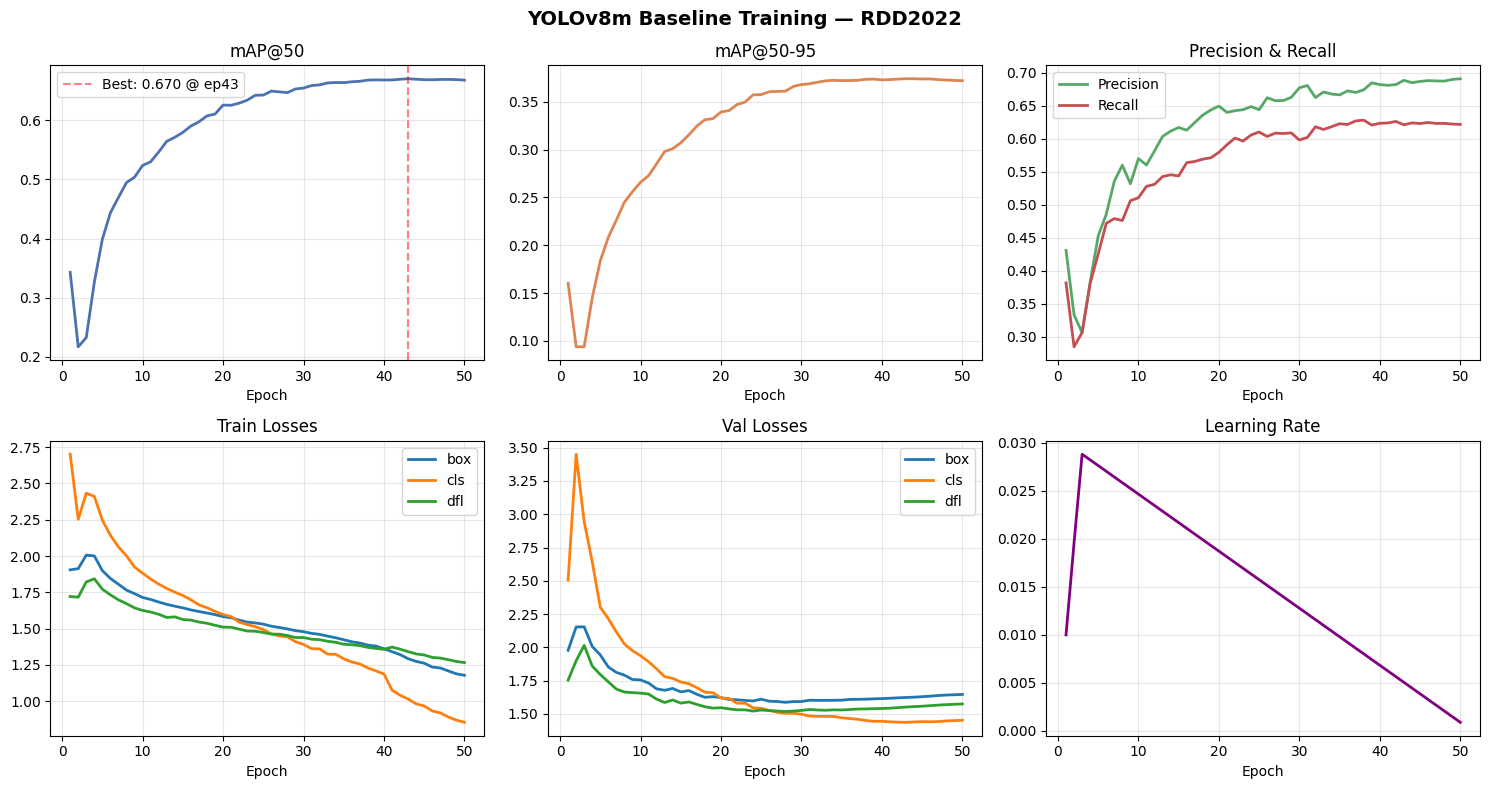

✓ Saved to /home/jupyter-st126222/Project/rdd2022/plots/baseline_training_curves.png


In [9]:
import pandas as pd

# Load results
results_df = pd.read_csv(SAVED_DIR / "yolov8m_rdd2022" / "results.csv")
results_df.columns = results_df.columns.str.strip()

# Find best epoch
best_epoch = results_df["metrics/mAP50(B)"].idxmax() + 1
best_map50 = results_df["metrics/mAP50(B)"].max()
best_map5095 = results_df.loc[results_df["metrics/mAP50(B)"].idxmax(), "metrics/mAP50-95(B)"]
best_precision = results_df.loc[results_df["metrics/mAP50(B)"].idxmax(), "metrics/precision(B)"]
best_recall = results_df.loc[results_df["metrics/mAP50(B)"].idxmax(), "metrics/recall(B)"]

print("=" * 50)
print("  YOLOv8m Baseline — Final Results (RDD2022)")
print("=" * 50)
print(f"  Best epoch     : {best_epoch} / 50")
print(f"  mAP@50         : {best_map50:.4f}")
print(f"  mAP@50-95      : {best_map5095:.4f}")
print(f"  Precision      : {best_precision:.4f}")
print(f"  Recall         : {best_recall:.4f}")
print(f"  Training time  : {results_df['time'].max()/3600:.1f} hrs")
print("=" * 50)

# Plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
epochs = results_df["epoch"]

# mAP50
axes[0,0].plot(epochs, results_df["metrics/mAP50(B)"], color="#4C72B0", linewidth=2)
axes[0,0].axvline(best_epoch, color="red", linestyle="--", alpha=0.5, label=f"Best: {best_map50:.3f} @ ep{best_epoch}")
axes[0,0].set_title("mAP@50")
axes[0,0].set_xlabel("Epoch")
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# mAP50-95
axes[0,1].plot(epochs, results_df["metrics/mAP50-95(B)"], color="#DD8452", linewidth=2)
axes[0,1].set_title("mAP@50-95")
axes[0,1].set_xlabel("Epoch")
axes[0,1].grid(alpha=0.3)

# Precision & Recall
axes[0,2].plot(epochs, results_df["metrics/precision(B)"], label="Precision", color="#55A868", linewidth=2)
axes[0,2].plot(epochs, results_df["metrics/recall(B)"], label="Recall", color="#C44E52", linewidth=2)
axes[0,2].set_title("Precision & Recall")
axes[0,2].set_xlabel("Epoch")
axes[0,2].legend()
axes[0,2].grid(alpha=0.3)

# Train losses
axes[1,0].plot(epochs, results_df["train/box_loss"], label="box", linewidth=2)
axes[1,0].plot(epochs, results_df["train/cls_loss"], label="cls", linewidth=2)
axes[1,0].plot(epochs, results_df["train/dfl_loss"], label="dfl", linewidth=2)
axes[1,0].set_title("Train Losses")
axes[1,0].set_xlabel("Epoch")
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Val losses
axes[1,1].plot(epochs, results_df["val/box_loss"], label="box", linewidth=2)
axes[1,1].plot(epochs, results_df["val/cls_loss"], label="cls", linewidth=2)
axes[1,1].plot(epochs, results_df["val/dfl_loss"], label="dfl", linewidth=2)
axes[1,1].set_title("Val Losses")
axes[1,1].set_xlabel("Epoch")
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

# Learning rate
axes[1,2].plot(epochs, results_df["lr/pg0"], color="purple", linewidth=2)
axes[1,2].set_title("Learning Rate")
axes[1,2].set_xlabel("Epoch")
axes[1,2].grid(alpha=0.3)

plt.suptitle("YOLOv8m Baseline Training — RDD2022", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "baseline_training_curves.png", dpi=150)
plt.show()
print(f"✓ Saved to {PLOTS_DIR / 'baseline_training_curves.png'}")

In [1]:
from ultralytics import YOLO
from pathlib import Path

BASE_DIR = Path("/home/jupyter-st126222/Project/rdd2022")
SAVED_DIR = BASE_DIR / "saved"
CLASSES = ["D00", "D10", "D20", "D40"]

model = YOLO(str(SAVED_DIR / "yolov8m_rdd2022" / "weights" / "best.pt"))
metrics = model.val(
    data=str(BASE_DIR / "data" / "rdd2022.yaml"),
    split="val",
    device=0
)

print(f"mAP@50     : {metrics.box.map50:.4f}")
print(f"mAP@50-95  : {metrics.box.map:.4f}")
print(f"\nPer-class AP@50:")
for cls_id, name in enumerate(CLASSES):
    print(f"  {name}: {metrics.box.ap50[cls_id]:.4f}")

Ultralytics 8.4.80 🚀 Python-3.12.6 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11004MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2219.0±972.2 MB/s, size: 355.2 KB)
val: Scanning /home/jupyter-st126222/Project/rdd2022/data/RDD_FILTERED/val/labels.cache... 5409 images, 2010 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5409/5409 945.3Mit/s 0.0s
val: /home/jupyter-st126222/Project/rdd2022/data/RDD_FILTERED/val/images/Japan_006536.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 339/339 5.6it/s 1:010.2sss
                   all       5409       8218       0.67      0.606      0.644      0.355
                   D00       1859       3678      0.659      0.535      0.582      0.324
                   D10       1010       1585      0.633       0.51      0.554      0.272
                   D20       1186    